# **Sistem Rekomendasi Restoran**
# 0.Import Library

In [1]:
import os, zipfile
import urllib.request
import numpy as np
import pandas as pd

# 1.Loading Dataset

In [2]:
# Download dataset
urllib.request.urlretrieve('https://archive.ics.uci.edu/ml/machine-learning-databases/00232/RCdata.zip', 'dataset.zip')

('dataset.zip', <http.client.HTTPMessage at 0x21e1e77fed0>)

In [3]:
with zipfile.ZipFile('dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('dataset')

In [4]:
accepts = pd.read_csv('dataset/chefmozaccepts.csv')
cuisine = pd.read_csv('dataset/chefmozcuisine.csv')
hours = pd.read_csv('dataset/chefmozhours4.csv')
parking = pd.read_csv('dataset/chefmozparking.csv')
geo = pd.read_csv('dataset/geoplaces2.csv', encoding = "ISO-8859-1")
usercuisine = pd.read_csv('dataset/usercuisine.csv')
payment = pd.read_csv('dataset/userpayment.csv')
profile = pd.read_csv('dataset/userprofile.csv')
rating = pd.read_csv('dataset/rating_final.csv')
 
print('Jumlah data pembayaran yang diterima restoran: ', len(accepts.placeID.unique()))
print('Jumlah data masakan pada restoran: ', len(cuisine.placeID.unique()))
print('Jumlah data waktu buka restoran: ', len(hours.placeID.unique()))
print('Jumlah data lokasi restoran: ', len(geo.placeID.unique()))
print('Jumlah data masakan pengguna: ', len(usercuisine.userID.unique()))
print('Jumlah data profil pengguna: ', len(profile.userID.unique()))
print('Jumlah data penilaian yang diberikan pengguna: ', len(rating.userID.unique()))
print('Jumlah data penilaian restoran: ', len(rating.placeID.unique()))

Jumlah data pembayaran yang diterima restoran:  615
Jumlah data masakan pada restoran:  769
Jumlah data waktu buka restoran:  694
Jumlah data lokasi restoran:  130
Jumlah data masakan pengguna:  138
Jumlah data profil pengguna:  138
Jumlah data penilaian yang diberikan pengguna:  138
Jumlah data penilaian restoran:  130


# 2.Univariate Exploratory Data Analysis 

In [5]:
accepts.info()

<class 'pandas.DataFrame'>
RangeIndex: 1314 entries, 0 to 1313
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   placeID   1314 non-null   int64
 1   Rpayment  1314 non-null   str  
dtypes: int64(1), str(1)
memory usage: 20.7 KB


In [6]:
print("Banyak data: ", len(accepts.placeID.unique()))
print("Jenis Pembayaran yang diterima: ", accepts.Rpayment.unique())

Banyak data:  615
Jenis Pembayaran yang diterima:  <StringArray>
[               'cash',                'VISA', 'MasterCard-Eurocard',
    'American_Express',    'bank_debit_cards',              'checks',
            'Discover',       'Carte_Blanche',         'Diners_Club',
                'Visa', 'Japan_Credit_Bureau',   'gift_certificates']
Length: 12, dtype: str


In [7]:
cuisine.info()

<class 'pandas.DataFrame'>
RangeIndex: 916 entries, 0 to 915
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   placeID   916 non-null    int64
 1   Rcuisine  916 non-null    str  
dtypes: int64(1), str(1)
memory usage: 14.4 KB


In [8]:
print("Banyak tipe masakan: ", len(cuisine.Rcuisine.unique()))
print("Tipe masakan: ", cuisine.Rcuisine.unique())

Banyak tipe masakan:  59
Tipe masakan:  <StringArray>
[             'Spanish',              'Italian',       'Latin_American',
              'Mexican',            'Fast_Food',              'Burgers',
    'Dessert-Ice_Cream',             'Hot_Dogs',               'Steaks',
                'Asian',        'International',            'Mongolian',
           'Vegetarian',            'Brazilian',     'Cafe-Coffee_Shop',
            'Cafeteria',         'Contemporary',      'Deli-Sandwiches',
                'Diner',             'Japanese',                'Sushi',
              'Seafood',              'Chinese',                  'Bar',
      'Bar_Pub_Brewery',             'Pizzeria',        'Mediterranean',
             'American',               'Family',            'Caribbean',
              'African',     'Breakfast-Brunch',             'Regional',
               'Afghan',               'Bakery',                 'Game',
             'Armenian',           'Vietnamese',               'Korean

In [9]:
profile.shape

(138, 19)

In [10]:
profile.head()

,userID,latitude,longitude,smoker,drink_level,dress_preference,ambience,transport,marital_status,hijos,birth_year,interest,personality,religion,activity,color,weight,budget,height
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,1989,variety,thrifty-protector,none,student,black,69,medium,1.77
1,U1002,22.150087,-100.983325,false,abstemious,informal,family,public,single,independent,1990,technology,hunter-ostentatious,Catholic,student,red,40,low,1.87
2,U1003,22.119847,-100.946527,false,social drinker,formal,family,public,single,independent,1989,none,hard-worker,Catholic,student,blue,60,low,1.69
3,U1004,18.867000,-99.183000,false,abstemious,informal,family,public,single,independent,1940,variety,hard-worker,none,professional,green,44,medium,1.53
4,U1005,22.183477,-100.959891,false,abstemious,no preference,family,public,single,independent,1992,none,thrifty-protector,Catholic,student,black,65,medium,1.69


In [11]:
rating.head()

,userID,placeID,rating,food_rating,service_rating
0,U1077,135085,2,2,2
1,U1077,135038,2,2,1
2,U1077,132825,2,2,2
3,U1077,135060,1,2,2
4,U1068,135104,1,1,2


In [12]:
rating.describe()

,placeID,rating,food_rating,service_rating
count,1161.000000,1161.000000,1161.000000,1161.000000
mean,134192.041344,1.199828,1.215332,1.090439
std,1100.916275,0.773282,0.792294,0.790844
min,132560.000000,0.000000,0.000000,0.000000
25%,132856.000000,1.000000,1.000000,0.000000
50%,135030.000000,1.000000,1.000000,1.000000
75%,135059.000000,2.000000,2.000000,2.000000
max,135109.000000,2.000000,2.000000,2.000000


In [13]:
print("Jumlah userID: ", len(rating.userID.unique()))
print("Jumlah placeID: ", len(rating.placeID.unique()))
print("Jumlah data rating: ", len(rating))

Jumlah userID:  138
Jumlah placeID:  130
Jumlah data rating:  1161


# 3.Data Preprocessing

In [14]:
# Menggabungkan seluruh placeID pada kategori restaurant
resto_all = np.concatenate((
    accepts.placeID.unique(),
    cuisine.placeID.unique(),
    hours.placeID.unique(),
    parking.placeID.unique(),
    geo.placeID.unique()
))
 
# Mengurutkan data dan menghapus data yang sama
resto_all = np.sort(np.unique(resto_all))
 
print('Jumlah seluruh data restoran berdasarkan placeID: ', len(resto_all))

Jumlah seluruh data restoran berdasarkan placeID:  938


In [15]:
# Menggabungkan seluruh userID
user_all = np.concatenate((
    usercuisine.userID.unique(),
    payment.userID.unique(),
    profile.userID.unique()
))
 
# Menghapus data yang sama kemudian mengurutkannya
user_all = np.sort(np.unique(user_all)) 
 
print('Jumlah seluruh user: ', len(user_all))

Jumlah seluruh user:  138


In [16]:
# Menggabungkan file accepts, geo, parking, hours ke dalam dataframe resto_info 
resto_info = pd.concat([accepts, geo, parking, hours])
 
# Menggabungkan dataframe rating dengan resto_info berdasarkan nilai placeID
resto = pd.merge(rating, resto_info , on='placeID', how='left')
resto

,userID,placeID,rating,food_rating,service_rating,Rpayment,latitude,longitude,the_geom_meter,name,...,accessibility,price,url,Rambience,franchise,area,other_services,parking_lot,hours,days
0,U1077,135085,2,2,2,cash,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,U1077,135085,2,2,2,NaN,22.150802,-100.982680,0101000020957F00009F823DA6094858C18A2D4D37F9A4...,Tortas Locas Hipocampo,...,no_accessibility,medium,?,familiar,f,closed,none,NaN,NaN,NaN
2,U1077,135085,2,2,2,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,public,NaN,NaN
3,U1077,135085,2,2,2,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,00:00-00:00;,Mon;Tue;Wed;Thu;Fri;
4,U1077,135085,2,2,2,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,00:00-00:00;,Sat;
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8073,U1068,132660,0,0,0,NaN,23.752943,-99.164679,0101000020957F00003D7905C9DC8157C13FCD1AB7334E...,carnitas mata calle Emilio Portes Gil,...,completely,low,?,familiar,f,closed,none,NaN,NaN,NaN
8074,U1068,132660,0,0,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,none,NaN,NaN
8075,U1068,132660,0,0,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,00:00-23:30;,Mon;Tue;Wed;Thu;Fri;
8076,U1068,132660,0,0,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,00:00-23:30;,Sat;


In [17]:
missing = pd.DataFrame({
    'Missing': resto.isnull().sum(),
    'Persentase': (resto.isnull().sum() * 100 / len(resto)).round(2)
})

missing

,Missing,Persentase
userID,0,0.00
placeID,0,0.00
rating,0,0.00
food_rating,0,0.00
service_rating,0,0.00
Rpayment,5781,71.56
latitude,6917,85.63
longitude,6917,85.63
the_geom_meter,6917,85.63
name,6917,85.63


In [18]:
# Menghitung jumlah rating, food_rating, dan service kemudian menggabungkannya berdasarkan placeID
resto.groupby('placeID').sum()

,userID,rating,food_rating,service_rating,Rpayment,latitude,longitude,the_geom_meter,name,address,...,accessibility,price,url,Rambience,franchise,area,other_services,parking_lot,hours,days
placeID,,,,,,,,,,,,,,,,,,,,,
132560,U1067U1067U1067U1067U1067U1067U1082U1082U1082U...,12,24,6,cashcashcashcash,95.009216,-396.667653,0101000020957F0000FC60BDA8E88157C1B2C357D6DA4E...,puesto de gorditaspuesto de gorditaspuesto de ...,frente al tecnologicofrente al tecnologicofren...,...,no_accessibilityno_accessibilityno_accessibili...,lowlowlowlow,????,familiarfamiliarfamiliarfamiliar,ffff,openopenopenopen,nonenonenonenone,publicpublicpublicpublic,08:00-12:00;00:00-00:00;00:00-00:00;08:00-12:0...,Mon;Tue;Wed;Thu;Fri;Sat;Sun;Mon;Tue;Wed;Thu;Fr...
132561,U1026U1026U1026U1026U1026U1129U1129U1129U1129U...,15,20,20,,94.907276,-396.506024,0101000020957F000004457BB7AA8657C15F10835CD944...,cafe ambarcafe ambarcafe ambarcafe ambar,????,...,completelycompletelycompletelycompletely,lowlowlowlow,????,familiarfamiliarfamiliarfamiliar,ffff,closedclosedclosedclosed,nonenonenonenone,nonenonenonenone,00:00-23:30;00:00-23:30;00:00-23:30;00:00-23:3...,Mon;Tue;Wed;Thu;Fri;Sat;Sun;Mon;Tue;Wed;Thu;Fr...
132564,U1060U1060U1060U1060U1060U1080U1080U1080U1080U...,25,25,30,,94.923698,-396.580739,0101000020957F0000EA4F00C5A08557C140085474D949...,churchschurchschurchschurchs,????,...,completelycompletelycompletelycompletely,lowlowlowlow,????,familiarfamiliarfamiliarfamiliar,ffff,closedclosedclosedclosed,nonenonenonenone,nonenonenonenone,00:00-23:30;00:00-23:30;00:00-23:30;00:00-23:3...,Mon;Tue;Wed;Thu;Fri;Sat;Sun;Mon;Tue;Wed;Thu;Fr...
132572,U1108U1108U1108U1108U1108U1108U1055U1055U1055U...,90,90,84,cashcashcashcashcashcashcashcashcashcashcashca...,332.124707,-1514.890677,0101000020957F00005D19BF45294958C18FF7F8E260A8...,Cafe ChairesCafe ChairesCafe ChairesCafe Chair...,???????????????,...,completelycompletelycompletelycompletelycomple...,lowlowlowlowlowlowlowlowlowlowlowlowlowlowlow,???????????????,familiarfamiliarfamiliarfamiliarfamiliarfamili...,fffffffffffffff,closedclosedclosedclosedclosedclosedclosedclos...,nonenonenonenonenonenonenonenonenonenonenoneno...,yesyesyesyesyesyesyesyesyesyesyesyesyesyesyes,00:00-23:30;00:00-23:30;00:00-23:30;00:00-23:3...,Mon;Tue;Wed;Thu;Fri;Sat;Sun;Mon;Tue;Wed;Thu;Fr...
132583,U1044U1044U1044U1044U1044U1044U1118U1118U1118U...,24,24,30,cashVISAMasterCard-Eurocardbank_debit_cardscas...,75.689162,-396.937328,0101000020957F0000FBE7171F056F5AC1E8A6C0A5AF55...,McDonalds CentroMcDonalds CentroMcDonalds Cent...,Rayon sn col. CentroRayon sn col. CentroRayon ...,...,partiallypartiallypartiallypartially,lowlowlowlow,nononono,familiarfamiliarfamiliarfamiliar,tttt,closedclosedclosedclosed,nonenonenonenone,nonenonenonenone,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135088,U1044U1044U1044U1044U1044U1044U1030U1030U1030U...,36,42,36,cashcashcashcashcashcash,113.256068,-595.319338,0101000020957F0000E14AD4DBC7765AC1F7B33C85B153...,Cafeteria cenidetCafeteria cenidetCafeteria ce...,Interior Internado Palmira SNInterior Internad...,...,no_accessibilityno_accessibilityno_accessibili...,lowlowlowlowlowlow,www.cenidet.edu.mxwww.cenidet.edu.mxwww.cenide...,quietquietquietquietquietquiet,ffffff,closedclosedclosedclosedclosedclosed,nonenonenonenonenonenone,publicpublicpublicpublicpublicpublic,09:00-16:00;00:00-00:00;00:00-00:00;09:00-16:0...,Mon;Tue;Wed;Thu;Fri;Sat;Sun;Mon;Tue;Wed;Thu;Fr...
135104,U1068U1068U1068U1068U1068U1068U1068U1068U1067U...,48,80,48,cashVISAMasterCard-EurocardcashVISAMasterCard-...,166.270875,-694.179039,0101000020957F00007CDF5EAFC58157C1645743B23E4F...,vipsvipsvipsvipsvipsvipsvips,???????,...,completelycompletelycompletelycompletelycomple...,mediummediummediummediummediummediummedium,???????,familiarfamiliarfamiliarfamiliarfamiliarfamili...,ttttttt,closedclosedclosedclosedclosedclosedclosed,varietyvarietyvarietyvarietyvarietyvarietyvariety,yesyesyesyesyesyesyes,00:00-23:30;00:00-23:30;00:00-2

In [19]:
# Definisikan dataframe rating ke dalam variabel all_resto_rate
all_resto_rate = rating
all_resto_rate

,userID,placeID,rating,food_rating,service_rating
0,U1077,135085,2,2,2
1,U1077,135038,2,2,1
2,U1077,132825,2,2,2
3,U1077,135060,1,2,2
4,U1068,135104,1,1,2
...,...,...,...,...,...
1156,U1043,132630,1,1,1
1157,U1011,132715,1,1,0
1158,U1068,132733,1,1,0
1159,U1068,132594,1,1,1


In [20]:
# Menggabungkan all resto_rate dengan dataframe geo berdasarkan placeID
all_resto_name = pd.merge(all_resto_rate, geo[['placeID','name']], on='placeID', how='left')
 
# Print dataframe all_resto_name
all_resto_name

,userID,placeID,rating,food_rating,service_rating,name
0,U1077,135085,2,2,2,Tortas Locas Hipocampo
1,U1077,135038,2,2,1,Restaurant la Chalita
2,U1077,132825,2,2,2,puesto de tacos
3,U1077,135060,1,2,2,Restaurante Marisco Sam
4,U1068,135104,1,1,2,vips
...,...,...,...,...,...,...
1156,U1043,132630,1,1,1,palomo tec
1157,U1011,132715,1,1,0,tacos de la estacion
1158,U1068,132733,1,1,0,Little Cesarz
1159,U1068,132594,1,1,1,tacos de barbacoa enfrente del Tec


In [21]:
# Menggabungkan dataframe cuisine dengan all_resto_name dan memasukkannya ke dalam variabel all_resto 
all_resto = pd.merge(all_resto_name, cuisine, on='placeID', how='left')
all_resto

,userID,placeID,rating,food_rating,service_rating,name,Rcuisine
0,U1077,135085,2,2,2,Tortas Locas Hipocampo,Fast_Food
1,U1077,135038,2,2,1,Restaurant la Chalita,NaN
2,U1077,132825,2,2,2,puesto de tacos,Mexican
3,U1077,135060,1,2,2,Restaurante Marisco Sam,Seafood
4,U1068,135104,1,1,2,vips,Mexican
...,...,...,...,...,...,...,...
1326,U1043,132630,1,1,1,palomo tec,Mexican
1327,U1011,132715,1,1,0,tacos de la estacion,Mexican
1328,U1068,132733,1,1,0,Little Cesarz,Pizzeria
1329,U1068,132594,1,1,1,tacos de barbacoa enfrente del Tec,Mexican


In [22]:
missing = pd.DataFrame({
    'Missing': all_resto.isnull().sum(),
    'Persentase': (all_resto.isnull().sum() * 100 / len(all_resto)).round(2)
})

missing

,Missing,Persentase
userID,0,0.00
placeID,0,0.00
rating,0,0.00
food_rating,0,0.00
service_rating,0,0.00
name,0,0.00
Rcuisine,288,21.64


In [23]:
# Membersihkan missing value dengan fungsi dropna()
all_resto_clean = all_resto.dropna()
all_resto_clean

,userID,placeID,rating,food_rating,service_rating,name,Rcuisine
0,U1077,135085,2,2,2,Tortas Locas Hipocampo,Fast_Food
2,U1077,132825,2,2,2,puesto de tacos,Mexican
3,U1077,135060,1,2,2,Restaurante Marisco Sam,Seafood
4,U1068,135104,1,1,2,vips,Mexican
5,U1068,132740,0,0,0,Carreton de Flautas y Migadas,Mexican
...,...,...,...,...,...,...,...
1325,U1043,132732,1,1,1,Taqueria EL amigo,Mexican
1326,U1043,132630,1,1,1,palomo tec,Mexican
1327,U1011,132715,1,1,0,tacos de la estacion,Mexican
1328,U1068,132733,1,1,0,Little Cesarz,Pizzeria


In [24]:
# Mengecek kembali missing value pada variabel all_resto_clean
all_resto_clean.isnull().sum()

userID            0
placeID           0
rating            0
food_rating       0
service_rating    0
name              0
Rcuisine          0
dtype: int64

In [25]:
# Mengurutkan resto berdasarkan PlaceID kemudian memasukkannya ke dalam variabel fix_resto
fix_resto = all_resto_clean.sort_values('placeID', ascending=True)
fix_resto

,userID,placeID,rating,food_rating,service_rating,name,Rcuisine
1288,U1050,132560,0,2,0,puesto de gorditas,Regional
42,U1082,132560,0,0,0,puesto de gorditas,Regional
1303,U1087,132560,1,2,1,puesto de gorditas,Regional
14,U1067,132560,1,0,0,puesto de gorditas,Regional
854,U1092,132572,1,0,0,Cafe Chaires,Cafeteria
...,...,...,...,...,...,...,...
189,U1055,135106,2,2,2,El Rincón de San Francisco,Mexican
1071,U1041,135109,1,2,1,Paniroles,Italian
99,U1030,135109,0,0,0,Paniroles,Italian
178,U1020,135109,2,2,1,Paniroles,Italian


In [26]:
# Mengecek berapa jumlah fix_resto
len(fix_resto.placeID.unique())

95

In [27]:
# Mengecek kategori masakan yang unik
fix_resto.Rcuisine.unique()

<StringArray>
[        'Regional',        'Cafeteria',         'American',
          'Mexican',        'Fast_Food',          'Italian',
         'Armenian',         'Pizzeria',         'Japanese',
       'Vietnamese',           'Family',    'International',
             'Game',          'Burgers',           'Bakery',
              'Bar', 'Breakfast-Brunch',  'Bar_Pub_Brewery',
    'Mediterranean', 'Cafe-Coffee_Shop',     'Contemporary',
          'Seafood',          'Chinese']
Length: 23, dtype: str

In [28]:
# Mengecek kategori masakan Game 
fix_resto[fix_resto['Rcuisine'] == 'Game']

,userID,placeID,rating,food_rating,service_rating,name,Rcuisine
781,U1015,132851,1,1,1,KFC,Game
708,U1008,132851,1,1,1,KFC,Game
509,U1052,132851,1,0,2,KFC,Game
1188,U1131,132851,2,2,2,KFC,Game
770,U1037,132851,2,2,1,KFC,Game
764,U1111,132851,2,1,0,KFC,Game
574,U1069,132851,1,0,0,KFC,Game


In [29]:
# Mengubah nama kategori masakan ‘Game’ menjadi ‘American’
fix_resto = fix_resto.replace('Game', 'American')
fix_resto[fix_resto['name'] == 'KFC']

,userID,placeID,rating,food_rating,service_rating,name,Rcuisine
573,U1069,132851,1,0,0,KFC,American
781,U1015,132851,1,1,1,KFC,American
708,U1008,132851,1,1,1,KFC,American
780,U1015,132851,1,1,1,KFC,American
763,U1111,132851,2,1,0,KFC,American
508,U1052,132851,1,0,2,KFC,American
509,U1052,132851,1,0,2,KFC,American
1188,U1131,132851,2,2,2,KFC,American
1187,U1131,132851,2,2,2,KFC,American
769,U1037,132851,2,2,1,KFC,American


In [30]:
# Membuat variabel preparation yang berisi dataframe fix_resto kemudian mengurutkan berdasarkan placeID
preparation = fix_resto
preparation.sort_values('placeID')

,userID,placeID,rating,food_rating,service_rating,name,Rcuisine
1288,U1050,132560,0,2,0,puesto de gorditas,Regional
42,U1082,132560,0,0,0,puesto de gorditas,Regional
1303,U1087,132560,1,2,1,puesto de gorditas,Regional
14,U1067,132560,1,0,0,puesto de gorditas,Regional
854,U1092,132572,1,0,0,Cafe Chaires,Cafeteria
...,...,...,...,...,...,...,...
189,U1055,135106,2,2,2,El Rincón de San Francisco,Mexican
1071,U1041,135109,1,2,1,Paniroles,Italian
99,U1030,135109,0,0,0,Paniroles,Italian
178,U1020,135109,2,2,1,Paniroles,Italian


In [31]:
# Membuang data duplikat pada variabel preparation
preparation = preparation.drop_duplicates('placeID')
preparation

,userID,placeID,rating,food_rating,service_rating,name,Rcuisine
1288,U1050,132560,0,2,0,puesto de gorditas,Regional
854,U1092,132572,1,0,0,Cafe Chaires,Cafeteria
27,U1044,132583,1,2,1,McDonalds Centro,American
148,U1063,132584,2,1,1,Gorditas Dona Tota,Mexican
1304,U1087,132594,1,2,1,tacos de barbacoa enfrente del Tec,Mexican
...,...,...,...,...,...,...,...
1016,U1019,135086,0,0,0,Mcdonalds Parque Tangamanga,Burgers
179,U1051,135088,1,1,1,Cafeteria cenidet,Cafeteria
4,U1068,135104,1,1,2,vips,Mexican
807,U1135,135106,0,0,0,El Rincón de San Francisco,Mexican


In [32]:
# Mengonversi data series ‘placeID’ menjadi dalam bentuk list
resto_id = preparation['placeID'].tolist()
 
# Mengonversi data series ‘Name’ menjadi dalam bentuk list
resto_name = preparation['name'].tolist()
 
# Mengonversi data series ‘Rcuisine’ menjadi dalam bentuk list
resto_cuisine = preparation['Rcuisine'].tolist()
 
print(len(resto_id))
print(len(resto_name))
print(len(resto_cuisine))

95
95
95


In [ ]:
# Membuat dictionary untuk data ‘resto_id’, ‘resto_name’, dan ‘cuisine’
resto_new = pd.DataFrame({
    'id': resto_id,
    'resto_name': resto_name,
    'cuisine': resto_cuisine
})
resto_new

,id,resto_name,cuisine
0,132560,puesto de gorditas,Regional
1,132572,Cafe Chaires,Cafeteria
2,132583,McDonalds Centro,American
3,132584,Gorditas Dona Tota,Mexican
4,132594,tacos de barbacoa enfrente del Tec,Mexican
...,...,...,...
90,135086,Mcdonalds Parque Tangamanga,Burgers
91,135088,Cafeteria cenidet,Cafeteria
92,135104,vips,Mexican
93,135106,El Rincón de San Francisco,Mexican


In [ ]:
data = resto_new
data.sample(5)

,id,resto_name,cuisine
87,135075,Mariscos El Pescador,Seafood
66,135039,Restaurant de Mariscos de Picon,Seafood
1,132572,Cafe Chaires,Cafeteria
31,132851,KFC,American
85,135073,Restaurante Bar El Gallinero,Bar


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
 
# Inisialisasi TfidfVectorizer
tf = TfidfVectorizer()
 
# Melakukan perhitungan idf pada data cuisine
tf.fit(data['cuisine']) 
 
# Mapping array dari fitur index integer ke fitur nama
tf.get_feature_names_out() 

array(['american', 'armenian', 'bakery', 'bar', 'bar_pub_brewery',
       'breakfast', 'brunch', 'burgers', 'cafeteria', 'chinese',
       'contemporary', 'family', 'fast_food', 'international', 'italian',
       'japanese', 'mexican', 'pizzeria', 'regional', 'seafood',
       'vietnamese'], dtype=object)

In [ ]:
# Melakukan fit lalu ditransformasikan ke bentuk matrix
tfidf_matrix = tf.fit_transform(data['cuisine']) 
 
# Melihat ukuran matrix tfidf
tfidf_matrix.shape 

(95, 21)

# 4.Model Development dengan Content Based Filtering

In [39]:
# Membuat dataframe untuk melihat tf-idf matrix
# Kolom diisi dengan jenis masakan
# Baris diisi dengan nama resto
 
pd.DataFrame(
    tfidf_matrix.toarray(), 
    columns=tf.get_feature_names_out(),
    index=data.resto_name
).sample(21, axis=1).sample(10, axis=0)

,chinese,burgers,bar_pub_brewery,vietnamese,seafood,breakfast,bakery,regional,mexican,american,...,family,japanese,international,fast_food,pizzeria,cafeteria,italian,brunch,bar,armenian
resto_name,,,,,,,,,,,,,,,,,,,,,
Cenaduria El RincÃ³n de Tlaquepaque,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Tortas Locas Hipocampo,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
Hamburguesas Valle Dorado,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
La Posada del Virrey,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
El Rincon de San Francisco,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Sirlone,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
McDonalds Centro,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Chaires,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
tacos de barbacoa enfrente del Tec,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [40]:
from sklearn.metrics.pairwise import cosine_similarity
 
# Menghitung cosine similarity pada matrix tf-idf
cosine_sim = cosine_similarity(tfidf_matrix) 
cosine_sim

array([[1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 1., 0.],
       [0., 0., 0., ..., 1., 1., 0.],
       [0., 0., 0., ..., 0., 0., 1.]], shape=(95, 95))

In [41]:
# Membuat dataframe dari variabel cosine_sim dengan baris dan kolom berupa nama resto
cosine_sim_df = pd.DataFrame(cosine_sim, index=data['resto_name'], columns=data['resto_name'])
print('Shape:', cosine_sim_df.shape)
 
# Melihat similarity matrix pada setiap resto
cosine_sim_df.sample(5, axis=1).sample(10, axis=0)

Shape: (95, 95)


resto_name,El Oceano Dorado,tacos de barbacoa enfrente del Tec,Cabana Huasteca,Preambulo Wifi Zone Cafe,Hamburguesas La perica
resto_name,,,,,
Restaurante El Reyecito,0.0,0.0,0.0,0.0,0.0
Mariscos Tia Licha,0.0,0.0,0.0,0.0,0.0
TACOS CORRECAMINOS,1.0,1.0,1.0,0.0,1.0
Unicols Pizza,0.0,0.0,0.0,0.0,0.0
Restaurante Marisco Sam,0.0,0.0,0.0,0.0,0.0
Restaurant Bar Coty y Pablo,0.0,0.0,0.0,0.0,0.0
El Herradero Restaurante and Bar,0.0,0.0,0.0,0.0,0.0
little pizza Emilio Portes Gil,0.0,0.0,0.0,0.0,0.0
Hamburguesas saul,0.0,0.0,0.0,1.0,0.0


In [42]:
def resto_recommendations(nama_resto, similarity_data=cosine_sim_df, items=data[['resto_name', 'cuisine']], k=5):
    """
    Rekomendasi Resto berdasarkan kemiripan dataframe
 
    Parameter:
    ---
    nama_resto : tipe data string (str)
                Nama Restoran (index kemiripan dataframe)
    similarity_data : tipe data pd.DataFrame (object)
                      Kesamaan dataframe, simetrik, dengan resto sebagai 
                      indeks dan kolom
    items : tipe data pd.DataFrame (object)
            Mengandung kedua nama dan fitur lainnya yang digunakan untuk mendefinisikan kemiripan
    k : tipe data integer (int)
        Banyaknya jumlah rekomendasi yang diberikan
    ---
 
 
    Pada index ini, kita mengambil k dengan nilai similarity terbesar 
    pada index matrix yang diberikan (i).
    """
 
 
    # Mengambil data dengan menggunakan argpartition untuk melakukan partisi secara tidak langsung sepanjang sumbu yang diberikan    
    # Dataframe diubah menjadi numpy
    # Range(start, stop, step)
    index = similarity_data.loc[:,nama_resto].to_numpy().argpartition(
        range(-1, -k, -1))
    
    # Mengambil data dengan similarity terbesar dari index yang ada
    closest = similarity_data.columns[index[-1:-(k+2):-1]]
    
    # Drop nama_resto agar nama resto yang dicari tidak muncul dalam daftar rekomendasi
    closest = closest.drop(nama_resto, errors='ignore')
 
    return pd.DataFrame(closest).merge(items).head(k)

In [44]:
data[data.resto_name.eq('KFC')]

,id,resto_name,cuisine
31,132851,KFC,American


In [45]:
resto_recommendations("KFC")

,resto_name,cuisine
0,VIPS,American
1,tacos los volcanes,American
2,Pizzeria Julios,American
3,Sirlone,International
4,McDonalds Centro,American


# 5.Model Development dengan Collaborative Filtering

In [48]:
df = rating
df

,userID,placeID,rating,food_rating,service_rating
0,U1077,135085,2,2,2
1,U1077,135038,2,2,1
2,U1077,132825,2,2,2
3,U1077,135060,1,2,2
4,U1068,135104,1,1,2
...,...,...,...,...,...
1156,U1043,132630,1,1,1
1157,U1011,132715,1,1,0
1158,U1068,132733,1,1,0
1159,U1068,132594,1,1,1


In [49]:
# Mengubah userID menjadi list tanpa nilai yang sama
user_ids = df['userID'].unique().tolist()
print('list userID: ', user_ids)
 
# Melakukan encoding userID
user_to_user_encoded = {x: i for i, x in enumerate(user_ids)}
print('encoded userID : ', user_to_user_encoded)
 
# Melakukan proses encoding angka ke ke userID
user_encoded_to_user = {i: x for i, x in enumerate(user_ids)}
print('encoded angka ke userID: ', user_encoded_to_user)

list userID:  ['U1077', 'U1068', 'U1067', 'U1103', 'U1107', 'U1044', 'U1070', 'U1031', 'U1082', 'U1023', 'U1060', 'U1015', 'U1123', 'U1021', 'U1026', 'U1083', 'U1108', 'U1012', 'U1093', 'U1030', 'U1066', 'U1127', 'U1017', 'U1100', 'U1133', 'U1118', 'U1072', 'U1080', 'U1063', 'U1074', 'U1117', 'U1020', 'U1051', 'U1055', 'U1053', 'U1035', 'U1064', 'U1081', 'U1001', 'U1014', 'U1088', 'U1056', 'U1134', 'U1106', 'U1126', 'U1124', 'U1018', 'U1125', 'U1119', 'U1076', 'U1022', 'U1094', 'U1116', 'U1105', 'U1075', 'U1007', 'U1115', 'U1024', 'U1132', 'U1005', 'U1120', 'U1004', 'U1037', 'U1052', 'U1036', 'U1038', 'U1071', 'U1114', 'U1084', 'U1049', 'U1019', 'U1069', 'U1113', 'U1104', 'U1079', 'U1045', 'U1009', 'U1016', 'U1047', 'U1095', 'U1034', 'U1078', 'U1099', 'U1008', 'U1040', 'U1121', 'U1110', 'U1042', 'U1013', 'U1054', 'U1111', 'U1128', 'U1062', 'U1101', 'U1135', 'U1032', 'U1048', 'U1092', 'U1085', 'U1109', 'U1102', 'U1098', 'U1046', 'U1122', 'U1138', 'U1033', 'U1089', 'U1003', 'U1091', 'U10

In [50]:
# Mengubah userID menjadi list tanpa nilai yang sama
user_ids = df['userID'].unique().tolist()
print('list userID: ', user_ids)

# Melakukan encoding userID
user_to_user_encoded = {x: i for i, x in enumerate(user_ids)}
print('encoded userID : ', user_to_user_encoded)

# Melakukan proses encoding angka ke ke userID
user_encoded_to_user = {i: x for i, x in enumerate(user_ids)}
print('encoded angka ke userID: ', user_encoded_to_user)

list userID:  ['U1077', 'U1068', 'U1067', 'U1103', 'U1107', 'U1044', 'U1070', 'U1031', 'U1082', 'U1023', 'U1060', 'U1015', 'U1123', 'U1021', 'U1026', 'U1083', 'U1108', 'U1012', 'U1093', 'U1030', 'U1066', 'U1127', 'U1017', 'U1100', 'U1133', 'U1118', 'U1072', 'U1080', 'U1063', 'U1074', 'U1117', 'U1020', 'U1051', 'U1055', 'U1053', 'U1035', 'U1064', 'U1081', 'U1001', 'U1014', 'U1088', 'U1056', 'U1134', 'U1106', 'U1126', 'U1124', 'U1018', 'U1125', 'U1119', 'U1076', 'U1022', 'U1094', 'U1116', 'U1105', 'U1075', 'U1007', 'U1115', 'U1024', 'U1132', 'U1005', 'U1120', 'U1004', 'U1037', 'U1052', 'U1036', 'U1038', 'U1071', 'U1114', 'U1084', 'U1049', 'U1019', 'U1069', 'U1113', 'U1104', 'U1079', 'U1045', 'U1009', 'U1016', 'U1047', 'U1095', 'U1034', 'U1078', 'U1099', 'U1008', 'U1040', 'U1121', 'U1110', 'U1042', 'U1013', 'U1054', 'U1111', 'U1128', 'U1062', 'U1101', 'U1135', 'U1032', 'U1048', 'U1092', 'U1085', 'U1109', 'U1102', 'U1098', 'U1046', 'U1122', 'U1138', 'U1033', 'U1089', 'U1003', 'U1091', 'U10

In [51]:
# Mengubah placeID menjadi list tanpa nilai yang sama
resto_ids = df["placeID"].unique().tolist()

# Melakukan proses encoding placeID
resto_to_resto_encoded = {x: i for i, x in enumerate(resto_ids)}

# Melakukan proses encoding angka ke placeID
resto_encoded_to_resto = {i: x for i, x in enumerate(resto_ids)}

In [52]:
# Mapping userID ke dataframe user
df["user"] = df["userID"].map(user_to_user_encoded)

# Mapping placeID ke dataframe resto
df["resto"] = df["placeID"].map(resto_to_resto_encoded)

In [53]:
# Mendapatkan jumlah user
num_users = len(user_to_user_encoded)
print(num_users)

# Mendapatkan jumlah resto
num_resto = len(resto_encoded_to_resto)
print(num_resto)

# Mengubah rating menjadi nilai float
df["rating"] = df["rating"].values.astype(np.float32)

# Nilai minimum rating
min_rating = min(df["rating"])

# Nilai maksimal rating
max_rating = max(df["rating"])

print(
    "Number of User: {}, Number of Resto: {}, Min Rating: {}, Max Rating: {}".format(
        num_users, num_resto, min_rating, max_rating
    )
)

138
130
Number of User: 138, Number of Resto: 130, Min Rating: 0.0, Max Rating: 2.0


In [54]:
# Mengacak dataset
df = df.sample(frac=1, random_state=42)
df

,userID,placeID,rating,food_rating,service_rating,user,resto
538,U1052,132870,1.0,1,1,63,116
673,U1015,132869,2.0,2,2,11,115
578,U1047,132875,0.0,0,0,78,117
242,U1056,135076,2.0,2,2,41,71
1063,U1002,135106,1.0,1,1,125,64
...,...,...,...,...,...,...,...
1044,U1073,135065,0.0,0,0,123,94
1095,U1058,135062,2.0,2,2,124,76
1130,U1087,132660,1.0,1,0,132,14
860,U1029,132937,1.0,1,1,110,126


In [55]:
# Membuat variabel x untuk mencocokkan data user dan resto menjadi satu value
x = df[['user', 'resto']].values
 
# Membuat variabel y untuk membuat rating dari hasil 
y = df['rating'].apply(lambda x: (x - min_rating) / (max_rating - min_rating)).values
 
# Membagi menjadi 80% data train dan 20% data validasi
train_indices = int(0.8 * df.shape[0])
x_train, x_val, y_train, y_val = (
    x[:train_indices],
    x[train_indices:],
    y[:train_indices],
    y[train_indices:]
)

# 6. Training Model

In [59]:
import tensorflow as tf
from tensorflow.keras import layers


class RecommenderNet(tf.keras.Model):

    # Inisialisasi fungsi
    def __init__(self, num_users, num_resto, embedding_size, **kwargs):
        super(RecommenderNet, self).__init__(**kwargs)
        self.num_users = num_users
        self.num_resto = num_resto
        self.embedding_size = embedding_size
        self.user_embedding = tf.keras.layers.Embedding(  # layer embedding user
            num_users,
            embedding_size,
            embeddings_initializer="he_normal",
            embeddings_regularizer=tf.keras.regularizers.l2(1e-6),
        )
        self.user_bias = tf.keras.layers.Embedding(
            num_users, 1
        )  # layer embedding user bias
        self.resto_embedding = layers.Embedding(  # layer embeddings resto
            num_resto,
            embedding_size,
            embeddings_initializer="he_normal",
            embeddings_regularizer=tf.keras.regularizers.l2(1e-6),
        )
        self.resto_bias = tf.keras.layers.Embedding(
            num_resto, 1
        )  # layer embedding resto bias

    def call(self, inputs):
        user_vector = self.user_embedding(inputs[:, 0])
        user_bias = self.user_bias(inputs[:, 0])
        resto_vector = self.resto_embedding(inputs[:, 1])
        resto_bias = self.resto_bias(inputs[:, 1])

        dot_user_resto = tf.tensordot(user_vector, resto_vector, 2)

        x = dot_user_resto + user_bias + resto_bias

        return tf.nn.sigmoid(x)

In [63]:
model = RecommenderNet(num_users, num_resto, 50) # Inisiasi model

# Model compile 
model.compile(
    loss = tf.keras.losses.BinaryCrossentropy(),
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics = [tf.keras.metrics.RootMeanSquaredError()]
)

In [64]:
# Memulai training

history = model.fit(
    x=x_train, y=y_train, batch_size=8, epochs=100, validation_data=(x_val, y_val)
)

Epoch 1/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7019 - root_mean_squared_error: 0.4039 - val_loss: 0.6985 - val_root_mean_squared_error: 0.4043
Epoch 2/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6762 - root_mean_squared_error: 0.3880 - val_loss: 0.6948 - val_root_mean_squared_error: 0.4020
Epoch 3/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6599 - root_mean_squared_error: 0.3776 - val_loss: 0.6902 - val_root_mean_squared_error: 0.3992
Epoch 4/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6599 - root_mean_squared_error: 0.3774 - val_loss: 0.6864 - val_root_mean_squared_error: 0.3968
Epoch 5/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6436 - root_mean_squared_error: 0.3673 - val_loss: 0.6819 - val_root_mean_squared_error: 0.3940
Epoch 6/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6324 - root_mean_squared_error: 0.3603 - val_loss: 0.6765 - val_root_mean_squared_error: 0.3906
Epoch 7/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 1m

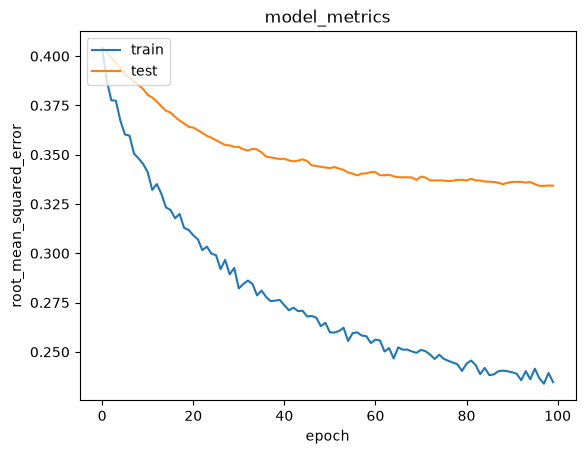

In [65]:
import matplotlib.pyplot as plt

plt.plot(history.history["root_mean_squared_error"])
plt.plot(history.history["val_root_mean_squared_error"])
plt.title("model_metrics")
plt.ylabel("root_mean_squared_error")
plt.xlabel("epoch")
plt.legend(["train", "test"], loc="upper left")
plt.show()

In [68]:
rating.to_csv('rating_final.csv')

In [69]:
resto_df = resto_new
df = pd.read_csv('rating_final.csv')
 
# Mengambil sample user
user_id = df.userID.sample(1).iloc[0]
resto_visited_by_user = df[df.userID == user_id]
 
# Operator bitwise (~), bisa diketahui di sini https://docs.python.org/3/reference/expressions.html 
resto_not_visited = resto_df[~resto_df['id'].isin(resto_visited_by_user.placeID.values)]['id'] 
resto_not_visited = list(
    set(resto_not_visited)
    .intersection(set(resto_to_resto_encoded.keys()))
)
 
resto_not_visited = [[resto_to_resto_encoded.get(x)] for x in resto_not_visited]
user_encoder = user_to_user_encoded.get(user_id)
user_resto_array = np.hstack(
    ([[user_encoder]] * len(resto_not_visited), resto_not_visited)
)

In [70]:
ratings = model.predict(user_resto_array).flatten()

top_ratings_indices = ratings.argsort()[-10:][::-1]
recommended_resto_ids = [
    resto_encoded_to_resto.get(resto_not_visited[x][0]) for x in top_ratings_indices
]

print("Showing recommendations for users: {}".format(user_id))
print("===" * 9)
print("Resto with high ratings from user")
print("----" * 8)

top_resto_user = (
    resto_visited_by_user.sort_values(by="rating", ascending=False)
    .head(5)
    .placeID.values
)

resto_df_rows = resto_df[resto_df["id"].isin(top_resto_user)]
for row in resto_df_rows.itertuples():
    print(row.resto_name, ":", row.cuisine)

print("----" * 8)
print("Top 10 resto recommendation")
print("----" * 8)

recommended_resto = resto_df[resto_df["id"].isin(recommended_resto_ids)]
for row in recommended_resto.itertuples():
    print(row.resto_name, ":", row.cuisine)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Showing recommendations for users: U1134
Resto with high ratings from user
--------------------------------
Restaurante El Reyecito : Fast_Food
Restaurant Bar Hacienda los Martinez : Bar
Mariscos El Pescador : Seafood
Tortas Locas Hipocampo : Fast_Food
--------------------------------
Top 10 resto recommendation
--------------------------------
La Estrella de Dimas : Mexican
Mariscos Tia Licha : Family
El cotorreo : Family
KFC : American
La Posada del Virrey : International
emilianos : Bar_Pub_Brewery
Restaurant Las Mananitas : International
Michiko Restaurant Japones : Japanese
El Herradero Restaurante and Bar : Bar
Restaurante Bar El Gallinero : Bar
